# Author Style Identification using LSTM

## Introduction

The objective of this project is to develop a machine learning model capable of identifying the **author** of a text excerpt based on writing style.

The dataset contains writings from three authors:

- **Edgar Allan Poe (EAP)**
- **H.P. Lovecraft (HPL)**
- **Mary Shelley (MWS)**

A **Long Short-Term Memory (LSTM)** neural network will be used because text data is sequential in nature and the order of words contributes to meaning and writing style.

Import the required libraries and load the dataset that will be used throughout the analysis.

In [4]:
import re
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 36
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_PATH = "Dataset part1.xlsx"

df = pd.read_excel(DATA_PATH)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (15442, 3)


,id,text,author
0,id17569,It never once occurred to me that the fumbling...,HPL
1,id11008,"In his left hand was a gold snuff box, from wh...",EAP
2,id27763,How lovely is spring As we looked from Windsor...,MWS
3,id22965,"A youth passed in solitude, my best years spen...",MWS
4,id13515,The surcingle hung in ribands from my body.,EAP


## Exploratory Data Analysis (EDA)

Initial assessment of the dataset by examining its structure, checking for missing values, assessing class balance, and analysing text length distributions. This helps identify any data quality issues and provides insight into the characteristics of the text before preprocessing and model development.

Dataset Shape: (15442, 3)


,id,text,author
0,id17569,It never once occurred to me that the fumbling...,HPL
1,id11008,"In his left hand was a gold snuff box, from wh...",EAP
2,id27763,How lovely is spring As we looked from Windsor...,MWS
3,id22965,"A youth passed in solitude, my best years spen...",MWS
4,id13515,The surcingle hung in ribands from my body.,EAP


Index(['id', 'text', 'author'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 15442 entries, 0 to 15441
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      15442 non-null  str  
 1   text    15442 non-null  str  
 2   author  15442 non-null  str  
dtypes: str(3)
memory usage: 362.1 KB

Missing Values:
id        0
text      0
author    0
dtype: int64


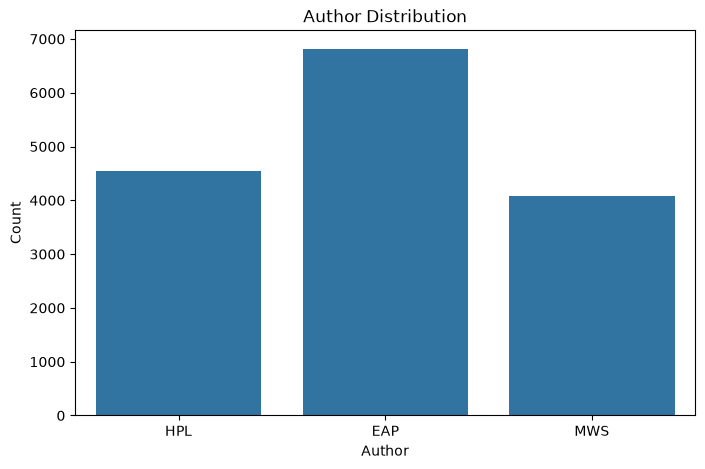


Text Length Summary:
count    15442.000000
mean       130.135021
std         87.723236
min         21.000000
25%         72.000000
50%        114.000000
75%        166.000000
max       3048.000000
Name: text_length, dtype: float64


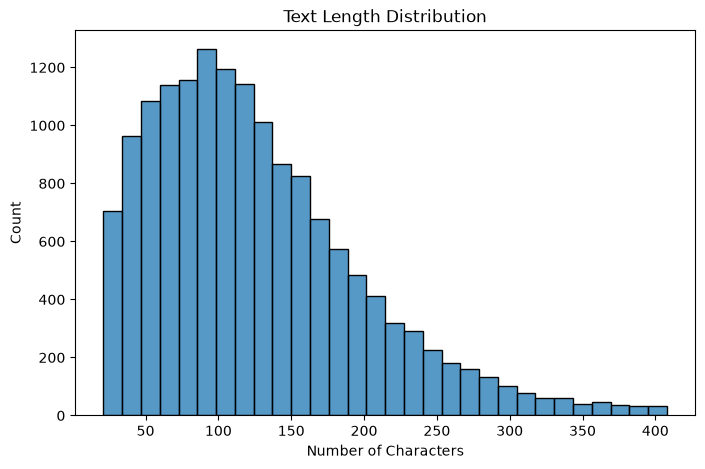

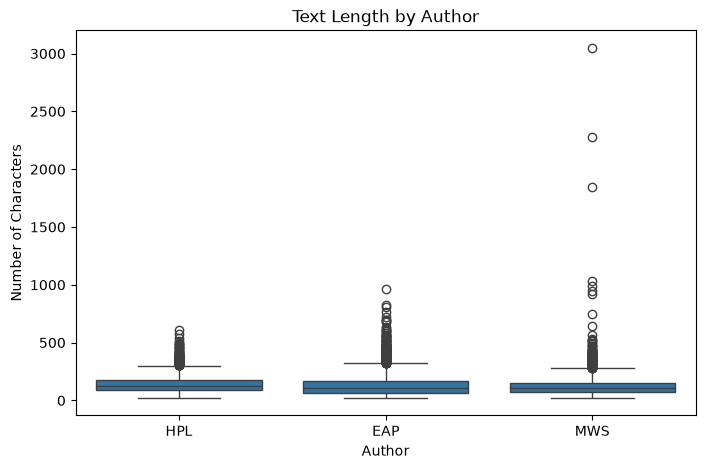

In [5]:
# Dataset overview
print(f"Dataset Shape: {df.shape}")
display(df.head())

print(df.columns)

# Data structure
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Author distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='author')
plt.title('Author Distribution')
plt.xlabel('Author')
plt.ylabel('Count')
plt.show()

# Text length analysis
df["text_length"] = df["text"].str.len()

print("\nText Length Summary:")
print(df["text_length"].describe())

upper_limit = df["text_length"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(
    df[df["text_length"] <= upper_limit]["text_length"],
    bins=30
)
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.show()

# Text length by author
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='author', y='text_length')
plt.title('Text Length by Author')
plt.xlabel('Author')
plt.ylabel('Number of Characters')
plt.show()

## Text Preprocessing and Feature Engineering

Prepare the text data for modelling by cleaning the text, converting words into numerical sequences, and transforming the target variable into a machine-readable format.
``

In [6]:
# Clean text

def clean_text(text):

    text = text.lower()

    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()


,text,clean_text
0,It never once occurred to me that the fumbling...,it never once occurred to me that the fumbling...
1,"In his left hand was a gold snuff box, from wh...",in his left hand was a gold snuff box from whi...
2,How lovely is spring As we looked from Windsor...,how lovely is spring as we looked from windsor...
3,"A youth passed in solitude, my best years spen...",a youth passed in solitude my best years spent...
4,The surcingle hung in ribands from my body.,the surcingle hung in ribands from my body


## Tokenisation and Sequence Preparation

Convert the cleaned text into numerical sequences, determine an appropriate sequence length, and prepare the data for input into the LSTM model.

In [7]:
# Convert text to sequences

MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_text"])

sequences = tokenizer.texts_to_sequences(df["clean_text"])

# Analyse sequence lengths

sequence_lengths = [len(seq) for seq in sequences]

print(pd.Series(sequence_lengths).describe())

count    15442.000000
mean        23.338039
std         15.675560
min          2.000000
25%         13.000000
50%         20.000000
75%         30.000000
max        594.000000
dtype: float64


## Encode Text and Author Labels

Convert the text sequences into a fixed-length format and encode the target author labels for multiclass classification.

In [8]:
# Pad sequences

MAX_LEN = 50

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

# Encode author labels

encoder = LabelEncoder()

y = encoder.fit_transform(df["author"])

y = to_categorical(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nAuthor Classes:")
print(encoder.classes_)

X shape: (15442, 50)
y shape: (15442, 3)

Author Classes:
['EAP' 'HPL' 'MWS']


## Train-Test Split

Split the data into training and testing sets to evaluate model performance on unseen observations.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (12353, 50)
Testing Features: (3089, 50)
Training Labels: (12353, 3)
Testing Labels: (3089, 3)


## Build the LSTM Model

Construct a Bidirectional LSTM network to learn writing patterns and classify text excerpts according to author.

In [11]:
model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_shape=(MAX_LEN,)
    ),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Temba\AppData\Local\anaconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\embedding.py:126: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,267 (5.29 MB)

 Trainable params: 1,387,267 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

Train the Bidirectional LSTM model using the training dataset and monitor validation performance to reduce overfitting.

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.6262 - loss: 0.8132 - val_accuracy: 0.7657 - val_loss: 0.5634
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.8608 - loss: 0.3559 - val_accuracy: 0.7863 - val_loss: 0.5648
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9318 - loss: 0.1992 - val_accuracy: 0.7819 - val_loss: 0.6676
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.9453 - loss: 0.1638 - val_accuracy: 0.7815 - val_loss: 0.7371


## Model Evaluation

Evaluate the trained model on the test dataset using multiple classification metrics.

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7669 - loss: 0.5717
Test Accuracy: 0.7669
Test Loss: 0.5717


## Classification Performance

Generate detailed classification metrics and assess model performance across all author classes.

In [14]:
pred_probs = model.predict(X_test)

pred_classes = pred_probs.argmax(axis=1)
actual_classes = y_test.argmax(axis=1)

print(
    classification_report(
        actual_classes,
        pred_classes,
        target_names=encoder.classes_
    )
)

97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
              precision    recall  f1-score   support

         EAP       0.82      0.75      0.78      1364
         HPL       0.82      0.74      0.78       910
         MWS       0.66      0.83      0.73       815

    accuracy                           0.77      3089
   macro avg       0.77      0.77      0.76      3089
weighted avg       0.78      0.77      0.77      3089



## Confusion Matrix

Visualise the distribution of correct and incorrect classifications for each author.
`

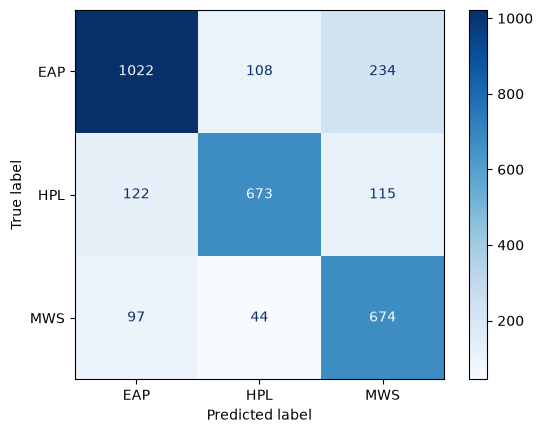

In [15]:
cm = confusion_matrix(actual_classes, pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

## Weighted F1 Score

Calculate the weighted F1 score to evaluate overall classification performance while accounting for class distribution.


In [16]:
f1 = f1_score(
    actual_classes,
    pred_classes,
    average="weighted"
)

print(f"Weighted F1 Score: {f1:.4f}")

Weighted F1 Score: 0.7685


### Results Interpretation

The Bidirectional LSTM achieved a test accuracy of **76.69%** and a weighted F1-score of approximately **0.77**, indicating good overall performance in distinguishing between the three authors.

From the confusion matrix, **Edgar Allan Poe (EAP)** was classified most accurately, with 1,022 correctly identified excerpts. **H.P. Lovecraft (HPL)** and **Mary Shelley (MWS)** also achieved reasonable classification performance, with 673 and 674 correct predictions respectively.

The largest source of misclassification occurred between **EAP and MWS**, suggesting similarities in writing patterns that made these authors more difficult for the model to distinguish. In contrast, MWS was least frequently confused with HPL, indicating stronger stylistic differences between these authors.

Overall, the model successfully learned author-specific writing patterns, although some overlap between writing styles resulted in classification errors.